<a href="https://colab.research.google.com/github/shivabasnet85/learning-pytorch-journey/blob/main/Copy_of_08_pytorch_paper_replicating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**In this notebook, we're going to be replicating the Vision Transformer(ViT) architecture/paper with PyTorch**:https://arxiv.org/pdf/2010.11929. **The goal of machine learning research paper replicating is: turn a ML research paper into usable code.**

**Get setup**

Let's import code we've previously written + required libraries

In [2]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12 or int(torch.__version__.split(".")[0]) == 2, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128


In [3]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4410, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4410 (delta 5), reused 2 (delta 2), pack-reused 4400 (from 2)
Receiving objects: 100% (4410/4410), 764.18 MiB | 30.84 MiB/s, done.
Resolving deltas: 100% (2661/2661), done.
Updating files: 100% (248/248), done.


In [4]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

**1. Get data**

The Whole goal of what we're trying to do is to replicate the ViT architecture for our FoodVision Mini problem.
To do that, we need some data.
Namely, the Pizza, steak and sushi images we've been using so far.

In [5]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] Did not find data/pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Unzipping pizza_steak_sushi.zip data...


PosixPath('data/pizza_steak_sushi')

In [6]:
# Setup directory paths to train and test images
train_dir = image_path / "train"
test_dir = image_path / "test"

In [7]:
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

**2.Create Datasets and DataLoaders**

In [8]:
from torchvision import transforms
from going_modular.going_modular import data_setup

# Create image size
IMG_SIZE = 224 # comes from Table of the ViT paper

# Create transforms pipeline
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [9]:
# Create a batch size of 32  (the paper uses 4096 but this may be too big for our smaller dataset)
BATCH_SIZE = 32

# Create DataLoaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=BATCH_SIZE
)

len(train_dataloader), len(test_dataloader), class_names

(8, 3, ['pizza', 'steak', 'sushi'])

**Visualize a single a image**

As always, let's adhere to the motto, visualize, visualize, visualize!


In [10]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image and label from the batch
image, label = image_batch[0], label_batch[0]

# View the single image and label shapes
image.shape, label

(torch.Size([3, 224, 224]), tensor(2))

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

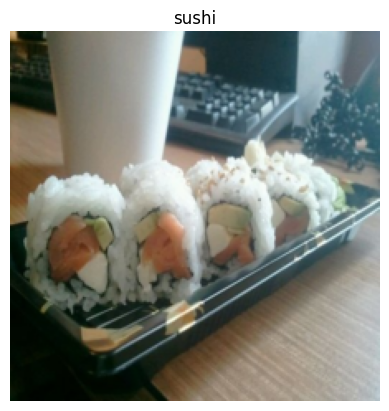

In [11]:
# Plot the image with matplotlib
import matplotlib.pyplot as plt

plt.imshow(image.permute(1, 2, 0)) # (color_channels, height, width) -> (height, width, color_channels)
plt.title(class_names[label])
plt.axis(False)


**3** **Replicating ViT: Overview**

Looking at a whole machine learning research paper can be intimidating.

So in order to make it more understandable , we can break it down into smaller pieces:

    - **Inputs **-  What goes into the model?(in our case, image tensors)
    - **Outputs**- What comes out of the model/layer/block?(in our case, we want the modelto output image classification labels.)
    - **Layer** - Takes an input, manipulates it with a function(for example could be self-attention).
    - **Blocks** - A collection of layers.
    - **Model** - A collection of blocks.



**3.1** **ViT overview: pieces of puzzle**

    - Figure 1 : Visual overview of the architecture
    - Four equations: math equations which define the fucntions of each layer/block.
    - Table 1/3: different hyperparameters for the architecture/training.
    - Text descriptions(especially section 3.1)


**Figure 1**

https://github.com/mrdbourke/pytorch-deep-learning/edit/main/images/08-vit-paper-figure-1-architecture-overview.png

* Embedding = learnable representation start with random numbers and improve over time.

**Four equations**

https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/08-vit-paper-four-equations.png

An overview of the model is depicted in Figure 1. The standard Transformer receives as input a 1D
sequence of token embeddings. To handle 2D images, we reshape the image x ∈ R
H×W×C into a
sequence of flattened 2D patches xp ∈ R
N×(P
2
·C)
, where (H, W) is the resolution of the original
image, C is the number of channels, (P, P) is the resolution of each image patch, and N = HW/P2
is the resulting number of patches, which also serves as the effective input sequence length for the
Transformer. The Transformer uses constant latent vector size D through all of its layers, so we
flatten the patches and map to D dimensions with a trainable linear projection (Eq. 1). We refer to
the output of this projection as the patch embeddings.
Similar to BERT’s [class] token, we prepend a learnable embedding to the sequence of embedded patches (z
0
0 = xclass), whose state at the output of the Transformer encoder (z
0
L
) serves as the
image representation y (Eq. 4). Both during pre-training and fine-tuning, a classification head is attached to z
0
L
. The classification head is implemented by a MLP with one hidden layer at pre-training
time and by a single linear layer at fine-tuning time.
Position embeddings are added to the patch embeddings to retain positional information. We use
standard learnable 1D position embeddings, since we have not observed significant performance
gains from using more advanced 2D-aware position embeddings (Appendix D.4). The resulting
sequence of embedding vectors serves as input to the encoder.
The Transformer encoder (Vaswani et al., 2017) consists of alternating layers of multiheaded selfattention (MSA, see Appendix A) and MLP blocks (Eq. 2, 3). Layernorm (LN) is applied before
every block, and residual connections after every block (Wang et al., 2019; Baevski & Auli, 2019).

**Equation 1:**

z0 = [xclass; x1pE; x2pE; · · ; xNp E] + Epos, E ∈ R(P2·C)×D,Epos ∈ R(N+1)×D (1)


In pseudocode:

```python
x_input = [class_token, image_patch_1, image_patch_2, ..image_patch_N] + [class_token_pos, image_patch_1_pos, image_patch_2_pos, ..image_patch_N_pos]
```

**Equation 2 & 3:**

z0` = MSA(LN(z`−1)) + z`−1, ` = 1 . . . L (2)

z` = MLP(LN(z0`)) + z0`, ` = 1 . . . L (3)

In pseudocode:

```python
x_output_MSA_block = MSA_layer(LN_layer(x_input)) + x_input (eq2)

x_output_MLP_block = MLP_layer(LN_layer(x_output_MSA_block)) + x_output_MSA_block. (eq3)

```

**Equation 4:**

Similar to BERT’s [class] token, we prepend a learnable embedding to the sequence of embedded patches (z00 = xclass), whose state at the output of the Transformer encoder (z0L) serves as theimage representation y (Eq. 4). Both during pre-training and fine-tuning, a classification head is attached to z0
L. The classification head is implemented by a MLP with one hidden layer at pre-training time and by a single linear layer at fine-tuning time.

* MLP = multilayer perception = a neural network with x number of layers
* MLP = one hidden layer at training time
* MLP = single linear layer at fine- tuning time
y = LN(z0L)      (4)

In pseudocode:

y = Linear_layer(LN_layer(x_output_MLP_block))



**Table 1**

https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/08-vit-paper-table-1.png


* ViT-Base, ViT-Large,  and ViT-Huge are all different sizes of the same model architecture.
* ViT-B/16 = ViT-Base with image patch size 16x16
* Layers - the number of transformer encoder layers
* Hidden size D - the embedding size throughout the architecture
* MLP size - the number of hidden units/neurons in the MLP
* Heads - the number of multi-head self-attention

4. Equation 1: Split the data into patches and creating the class, position and patch embedding

Layers = input -> function -> output

* Input shape: (224, 224, 3) -> single image -> (height, width, color channels)

* Input image: $H\times{W}\times{C}$
* Output image: ${N \times\left(P^{2} \cdot C\right)}$
* H = height
* W = width
* C = color channels
* P = patch size
* N = number of patches = (height*width)/ p^2
* D = constant latent vector size = embedding dimension

In [12]:
# Create example values
height = 224
width = 224
color_channels = 3
patch_size = 16

# Calculate the number of patches
number_of_patches =int ((height * width) / patch_size**2)
number_of_patches

196

In [13]:
# Input shape
embedding_layer_input_shape = (height, width, color_channels)

# Output shape
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

print(f"Input shape(single 2D image): {embedding_layer_input_shape}")
print(f"output shape (single 1D sequence of patches) : {embedding_layer_output_shape}")

Input shape(single 2D image): (224, 224, 3)
output shape (single 1D sequence of patches) : (196, 768)


**4.2 Turning a single image into patches**

Let's visualize, visualize, visualize

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

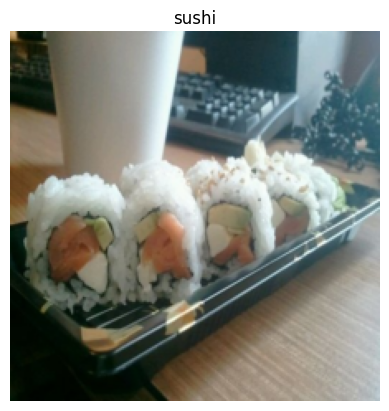

In [14]:
# View a single image
plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False)

In [15]:
image.shape

torch.Size([3, 224, 224])

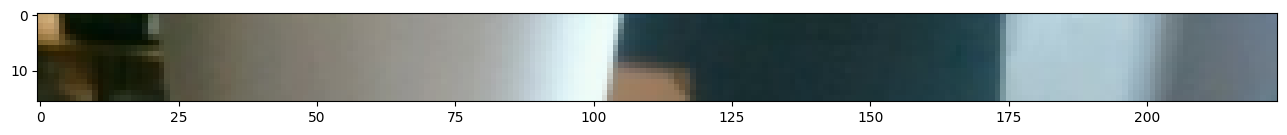

In [16]:
# Get the top row of the image
image_permuted = image.permute(1, 2, 0)# convert image to color channels last(H, W, C)

# Index to plot the top row of pixels
patch_size = 16
plt.figure(figsize=(patch_size, patch_size))
plt.imshow(image_permuted[:patch_size, :, :])

Number of patches per row: 14.0
Patch size: 16 pixels x 16 pixels


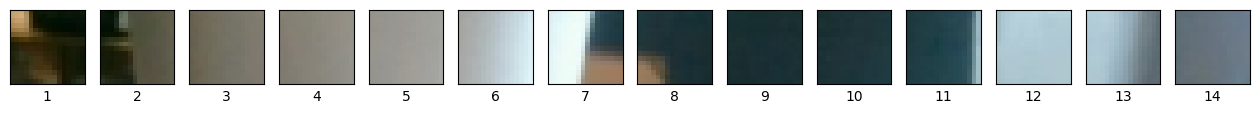

In [17]:
# Setup code to plot top row as patches
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=1,
                        ncols=img_size // patch_size, # one column for each patch
                        sharex=True,
                        sharey=True,
                        figsize=(patch_size, patch_size))
# Iterate through number of patches in the top row
for i, patch in enumerate(range(0, img_size, patch_size)):
    axs[i].imshow(image_permuted[:patch_size, patch:patch+patch_size, :])
    axs[i].set_xlabel(i+1)# set the patch label
    axs[i].set_xticks([])
    axs[i].set_yticks([])

Number of patches per row: 14.0
Number of patches per column: 14.0
Total patches: 196.0
Patch size: 16 pixels x 16 pixels 


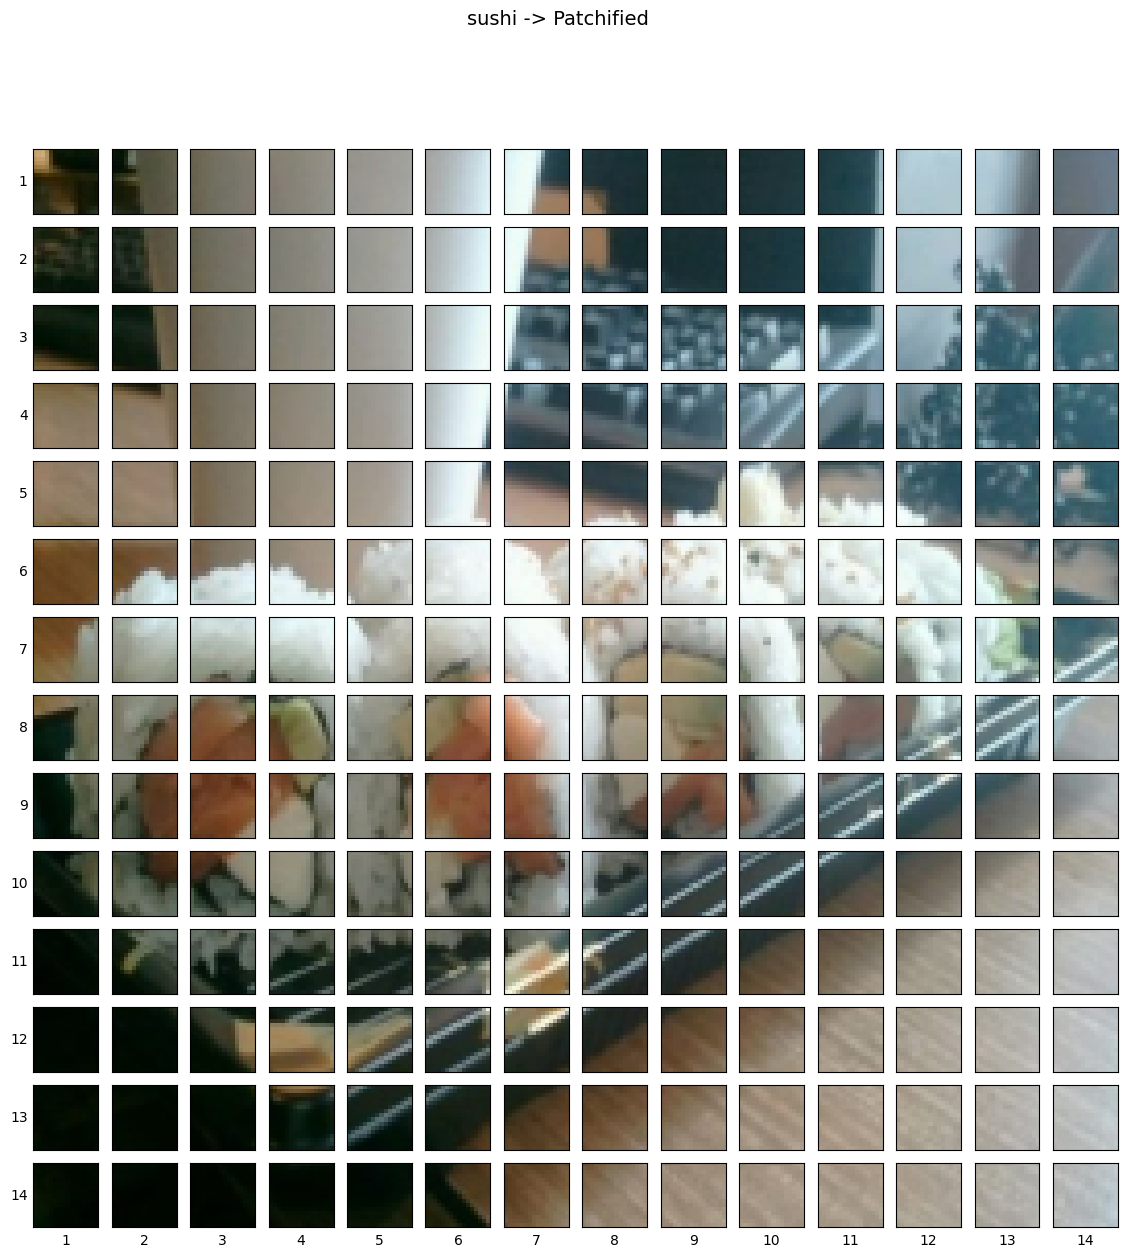

In [18]:
# Setup code to plot whole image as patches
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0,"Image size must be divisible by patch_size"
print(f"Number of patches per row: {num_patches}\
\nNumber of patches per column: {num_patches}\
\nTotal patches: {num_patches*num_patches}\
\nPatch size: {patch_size} pixels x {patch_size} pixels ")

# Create a series of subplots
fig, axs = plt.subplots(nrows=img_size // patch_size,
                        ncols=img_size // patch_size,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Loop through height and width of range
for i, patch_height in enumerate(range(0, img_size, patch_size)): # iterate through height
    for j, patch_width in enumerate(range(0, img_size, patch_size)): # iterate through width
        # Plot the permuted image on the different axes
        axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size, # iterate through height
                                    patch_width:patch_width+patch_size, # iterate through width
                                    :]) # get all color channels
        # Set up label information for each subplot (patch)
        axs[i, j].set_ylabel(i+1,
                         rotation="horizontal",
                         horizontalalignment="right",
                         verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i,j].set_yticks([])
        axs[i,j].label_outer()

# Set up a title for a plot
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=14)
plt.show()


**4.3 Creating image patches and turning them into patch embeddings**

Perhaps we could the image patches and image patch embeddings in a singke step using torch.nn.Conv2d() and setting the kernel size and stride parameters to patch_size.

In [19]:
# Create conv2d layer to turn image into patches of learnable feature maps (embeddings)
from torch import nn

# Set the patch size
patch_size = 16

# Create a conv2d layer with hyperparameters from the ViT paper
conv2d = nn.Conv2d(in_channels=3,# for color images
                   out_channels=768, # D size from the Table 1
                   kernel_size=patch_size,
                   stride=patch_size,
                   padding=0)
conv2d

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

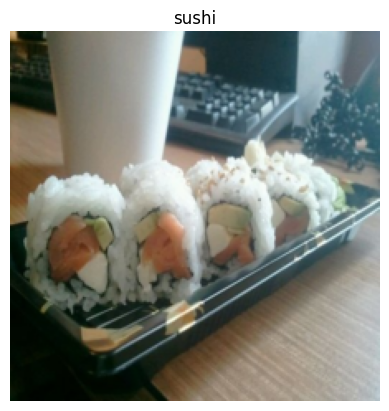

In [20]:
# View single image
plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False)

In [21]:
# Pass the image through the convolutional layer
image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension -> (batch_size, color_channels, height, width)
print(image_out_of_conv.shape)

torch.Size([1, 768, 14, 14])


Showing random convolutional feature maps from indexes: [420, 605, 390, 611, 609]


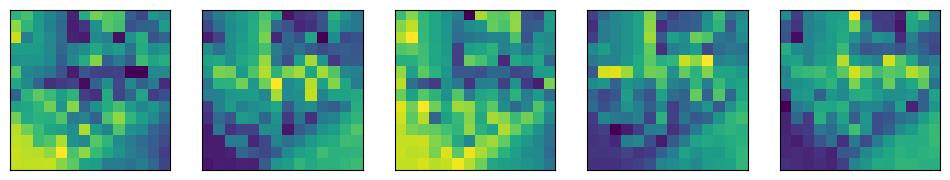

In [22]:
# Plot random convolutional feature maps (embeddings)
import random
random_indexes = random.sample(range(0, 758), k=5)
print(f"Showing random convolutional feature maps from indexes: {random_indexes}")

# Create plot
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12, 12))

# Plot random image feature maps
for i, idx in enumerate(random_indexes):
    image_conv_feature_map = image_out_of_conv[:, idx, :, :] # index on the output tensor of the conv2d layer
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy()) #remove batch dimension, and remove from grad tracking/switch to numpy for matplotlib
    axs[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

In [23]:
# Get a single feature map in tensor form
single_feature_map = image_out_of_conv[:, 0, :, :]
single_feature_map,single_feature_map.requires_grad

(tensor([[[ 2.6539e-02,  4.0612e-02, -4.4133e-02, -6.4705e-02, -9.3929e-02,
           -7.9407e-02, -3.2377e-01, -5.3778e-02, -4.5078e-03,  2.5010e-03,
            5.1401e-02, -1.1456e-01, -1.8143e-01, -5.2487e-02],
          [-1.4973e-02,  4.6054e-02, -3.5520e-02, -6.9397e-02, -8.7089e-02,
           -8.3828e-02, -2.2634e-01, -1.2689e-01, -1.0391e-02, -3.3393e-03,
            3.8114e-02, -1.0243e-01, -1.1051e-01, -6.5632e-02],
          [-2.8755e-02,  4.6509e-02, -4.5665e-02, -6.6961e-02, -7.4241e-02,
           -9.0792e-02, -4.6724e-02, -3.7189e-02, -6.4826e-02, -1.8343e-01,
           -1.7378e-01, -4.4225e-02, -9.5100e-03, -6.8964e-03],
          [-1.2855e-01, -1.7442e-01, -4.5692e-02, -8.0401e-02, -7.7575e-02,
           -1.9704e-01, -7.5219e-02, -4.0281e-03,  2.1806e-04, -9.4500e-02,
            2.4226e-03, -7.4353e-02, -2.4387e-02, -2.5219e-02],
          [-7.4031e-02, -8.2366e-02, -5.2908e-02, -8.3699e-02, -7.9252e-02,
           -1.4537e-01, -2.3041e-01, -1.5238e-01, -6.9215e-0

**4.4 Flattening the patch embedding with `torch.nn.Flatten()`**

Right now we've series of convolutional feature maps(patch embeddings) that we want to flatten into a sequence of patch embeddings to satisfy the input criteria of the ViT Transformer Encoder.






In [24]:
print(f"{image_out_of_conv.shape} -> (batch_size, embedding_dim, feature_map_height, feature_map_width)")

torch.Size([1, 768, 14, 14]) -> (batch_size, embedding_dim, feature_map_height, feature_map_width)


In [25]:
from torch import nn
flatten_layer = nn.Flatten(start_dim=2,
                           end_dim=3)

flatten_layer(image_out_of_conv).shape

torch.Size([1, 768, 196])

Original image shape: torch.Size([3, 224, 224])
Image feature map (patches) shape: torch.Size([1, 768, 14, 14])
Flattened image feature map shape: torch.Size([1, 768, 196])


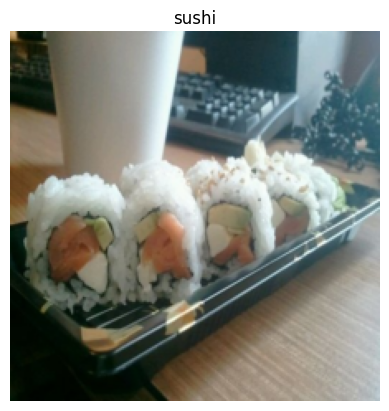

In [26]:
# Put everything together
plt.imshow(image.permute(1, 2, 0))
plt.title(class_names[label])
plt.axis(False)
print(f"Original image shape: {image.shape}")

# Turn image into feature maps
image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension
print(f"Image feature map (patches) shape: {image_out_of_conv.shape}")

# Flatten the feature maps
image_out_of_conv_flattened = flatten_layer(image_out_of_conv)
print(f"Flattened image feature map shape: {image_out_of_conv_flattened.shape}")

In [27]:
# Rearrange output of flattened layer
image_out_of_conv_flattened_permuted = image_out_of_conv_flattened.permute(0, 2, 1)
print(f"{image_out_of_conv_flattened.permute(0, 2, 1).shape} -> (batch_size, number_of_patches, embedding_dimension)")

torch.Size([1, 196, 768]) -> (batch_size, number_of_patches, embedding_dimension)


(np.float64(-0.5), np.float64(195.5), np.float64(0.5), np.float64(-0.5))

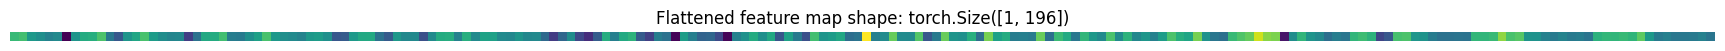

In [28]:
# Get a single flattened feature map
single_flattened_feature_map = image_out_of_conv_flattened_permuted[:,:,0]

# Plot the flattened feature map visually
plt.figure(figsize=(22, 22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"Flattened feature map shape: {single_flattened_feature_map.shape}")
plt.axis(False)


**4.5 Turning the ViT patch embedding layer into a PyTorch module**

We want this module to do a few things:

 1. Create a class called `PatchEmbedding` that inherits from nn.Module.
 2. Intialize with appropiate hyperparameters, such as channels, embedding dimension, patch size.
 3. Create a layer to turn an image into embedding patches using `nn.Conv2d()`.
 4. Create a layer to flatten the fature maps of the output of the layer in 3.
 5. Define a `forward()` that defines the forward computation(e.g pass through layer from 3 and 4).
 6. Make sure the output shape of the layer reflects the required output shape of the patch embedding.

In [31]:
# Create a PatchEmbedding class
class PatchEmbedding(nn.Module):
    # Intialize the layer with appropiate hyperparameters
    def __init__(self,
                 in_channels:int=3,
                 patch_size:int=16,
                 embedding_dim:int=768):
        super().__init__()

        self.patch_size = patch_size

        # Create a layer to turn an image into embedding patches
        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding=0)

        # Create a layer to flatten feature map output of conv2d
        self.flatten = nn.Flatten(start_dim=2,
                                  end_dim=3)

        # Define a forward method to define the forward computation steps
    def forward(self, x):
        # Create assertion to check that inputs are the correct shape
        image_resolution = x.shape[-1]
        assert image_resolution % patch_size == 0, f"Input image size must be divisible by patch size, image shape: {image_resolution}, patch size: {self.patch_size}"

        # Perform the forward pass
        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched)

        # Make the returned sequence embedding dimensions are in the right order(batch_dimension, number_of_patches, embedding_dimension)
        return x_flattened.permute(0, 2, 1)


In [32]:
set_seeds()

# Create an instance of patch embedding layer
patchify = PatchEmbedding(in_channels=3,
                          patch_size=16,
                          embedding_dim=768)

# Pass a single image through patch embedding layer
print(f"Input image size: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0)) # add an extra batch dimension
print(f"Output patch embedding sequence shape: {patch_embedded_image.shape}")

Input image size: torch.Size([1, 3, 224, 224])
Output patch embedding sequence shape: torch.Size([1, 196, 768])
